In [1]:
import qsample as qs
import time
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Toy model

In [2]:
p_phys = 0.1
t_max = 500

toy_model = ("""R 0"""+
(f"""
X_ERROR({p_phys}) 0
M 0
""")*t_max)

toy_circuit = stim.Circuit(toy_model)

sampler = toy_circuit.compile_sampler()
samples = sampler.sample(shots=10000)
T_ = []

for shot in samples:
    if sum(shot)>0:
        T_.append(list(shot).index(True)+1)

T_ = np.array(T_)
print(np.average(T_))




9.962


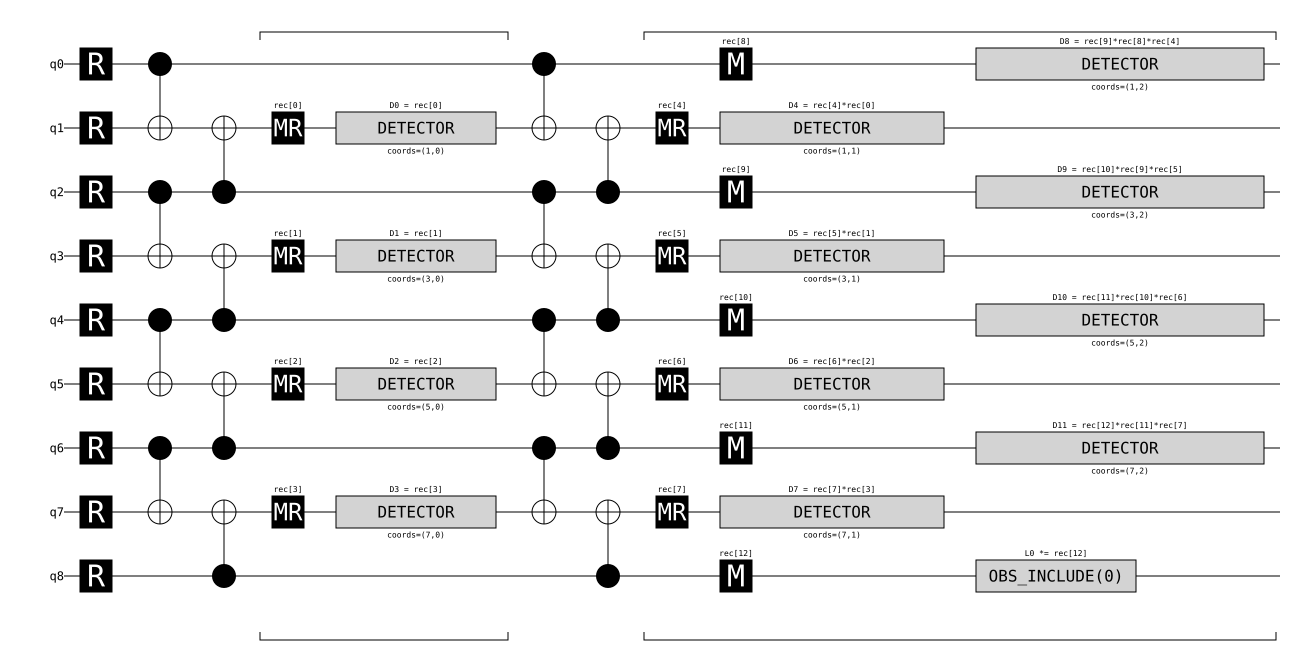

In [3]:
code = stim.Circuit.generated("repetition_code:memory", rounds=2, distance=5)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

code.diagram('timeline-svg')

[{'init': {0, 1, 2, 3, 4, 5, 6, 7, 8}}, {'CNOT': {(0, 1)}}, {'CNOT': {(2, 3)}}, {'CNOT': {(4, 5)}}, {'CNOT': {(6, 7)}}, {'CNOT': {(2, 1)}}, {'CNOT': {(4, 3)}}, {'CNOT': {(6, 5)}}, {'CNOT': {(8, 7)}}, {'measure': {1, 3, 5, 7}}, {'init': {1, 3, 5, 7}}, {'measure': {0, 2, 4, 6, 8}}]


p=('1.00e-01',): 100%|██████████| 2000/2000 [00:00<00:00, 11076.83it/s]


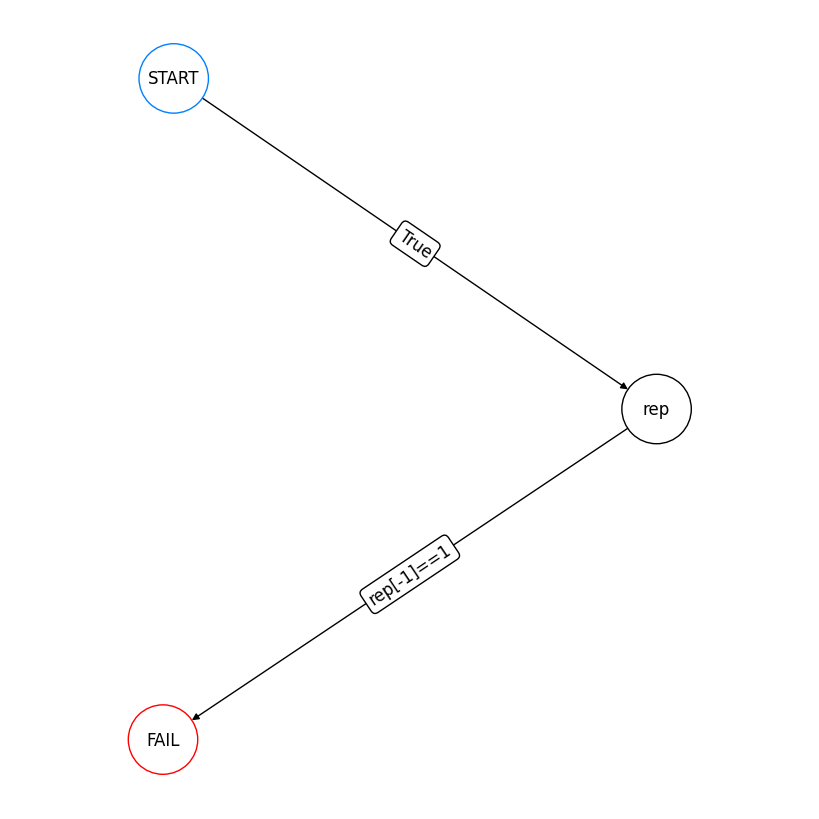

In [4]:
distance = 5
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=distance, before_round_data_depolarization=0.01,
              before_measure_flip_probability=0.01)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

DEM = code.detector_error_model(decompose_errors=True)
decoder = pymatching.Matching.from_detector_error_model(DEM)


print(rep_code._ticks)

functions = {}
rep = qs.Protocol(check_functions=functions)

round_ = 0
def reset_count():
    global round_
    round_=0
    return True

def increase_count():
    global round_
    round_+=1
    return round_

def count():
    global round_
    return round_

rep.add_nodes_from(['rep'], circuits=[rep_code])
rep.add_edge('START', 'rep', check='True')
rep.add_edge('rep', 'FAIL', check='rep[-1]==1')


rep.draw(figsize=(8,8), path='protocol_repetition')

err_model = qs.noise.E1
stim_sam = qs.LifetimeSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.1]}, err_model=err_model, distance=distance)

In [12]:
stim_sam.calculate_lifetime(8, 500, 0.01)

6.04

[array([0.015])]


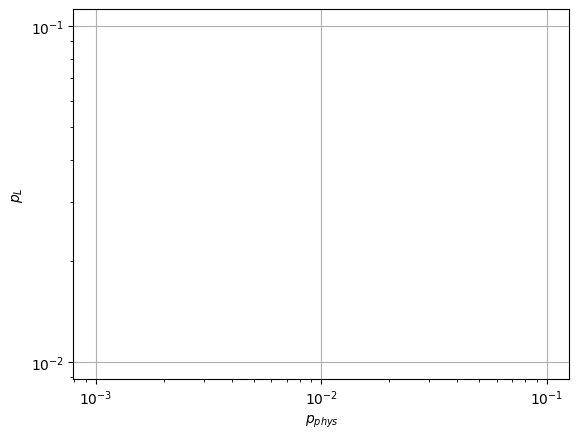

In [7]:
#stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
#stim_sam.calculate_error(0.0001, 8)
print(stim_sam.logical_p)
plt.plot(stim_sam.physical_p, stim_sam.logical_p)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$p_{phys}$')
plt.ylabel('$p_L$')
plt.grid()
